# Proyecto de Sprint 7:
## Análisis de ventas vehiculares visualizado mediante aplicativo web


### Descripción y objetivo del proyecto

### Verificar entorno de desarrollo

In [54]:
import sys
import os

print("Python:", sys.executable)
print("Carpeta:", os.getcwd())

Python: /Users/isaacnoriega/anaconda3/envs/entorno_sprint7/bin/python
Carpeta: /Users/isaacnoriega/Bootcamp_DS/Aplicativoweb_sprint7/Proyecto_sprint7/notebooks


### Importación de datos y librerias

In [55]:
import pandas as pd
import plotly.graph_objects as go
import seaborn as sns
import numpy as np
import missingno as msno

# Leer los datos del archivo CSV
df = pd.read_csv('../vehicles_us.csv')

### Análisis exploratorio de datos

Observaciones derivadas del análisis exploratorio:
1. El df tiene una dimensión de 13 columnas y 51,525 registros. 
2. Las variables: model_year, cylinders, odometer, paint_color e is_4wd, presentan valores nulos
3. Se deben ajustar los tipos de datos. model_year pasar a int, los que son object y pertenecen a un string, pasar a str, la fecha a datetime
4. Mediante describe, se observa que para las variables "price","odometer" y "days_listed" presentan un sesgo positivo a la derecha por lo que se presentan valores atípicos con mvalores muy altos. 
4. En cuanto a la distribución de los datos, se observa que: 

In [56]:
print(f'La dimensión del df es: {df.shape}')
display(df.info())
display(df.head())
display(df.describe())


La dimensión del df es: (51525, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51525 entries, 0 to 51524
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   price         51525 non-null  int64  
 1   model_year    47906 non-null  float64
 2   model         51525 non-null  object 
 3   condition     51525 non-null  object 
 4   cylinders     46265 non-null  float64
 5   fuel          51525 non-null  object 
 6   odometer      43633 non-null  float64
 7   transmission  51525 non-null  object 
 8   type          51525 non-null  object 
 9   paint_color   42258 non-null  object 
 10  is_4wd        25572 non-null  float64
 11  date_posted   51525 non-null  object 
 12  days_listed   51525 non-null  int64  
dtypes: float64(4), int64(2), object(7)
memory usage: 5.1+ MB


None

,price,model_year,model,condition,cylinders,fuel,odometer,transmission,type,paint_color,is_4wd,date_posted,days_listed
0,9400,2011.0,bmw x5,good,6.0,gas,145000.0,automatic,SUV,NaN,1.0,2018-06-23,19
1,25500,NaN,ford f-150,good,6.0,gas,88705.0,automatic,pickup,white,1.0,2018-10-19,50
2,5500,2013.0,hyundai sonata,like new,4.0,gas,110000.0,automatic,sedan,red,NaN,2019-02-07,79
3,1500,2003.0,ford f-150,fair,8.0,gas,NaN,automatic,pickup,NaN,NaN,2019-03-22,9
4,14900,2017.0,chrysler 200,excellent,4.0,gas,80903.0,automatic,sedan,black,NaN,2019-04-02,28


,price,model_year,cylinders,odometer,is_4wd,days_listed
count,51525.000000,47906.000000,46265.000000,43633.000000,25572.0,51525.00000
mean,12132.464920,2009.750470,6.125235,115553.461738,1.0,39.55476
std,10040.803015,6.282065,1.660360,65094.611341,0.0,28.20427
min,1.000000,1908.000000,3.000000,0.000000,1.0,0.00000
25%,5000.000000,2006.000000,4.000000,70000.000000,1.0,19.00000
50%,9000.000000,2011.000000,6.000000,113000.000000,1.0,33.00000
75%,16839.000000,2014.000000,8.000000,155000.000000,1.0,53.00000
max,375000.000000,2019.000000,12.000000,990000.000000,1.0,271.00000


In [57]:
# Observación de valores nulos: 

# Adecuación en la forma de mostrar los valores único, incluyendo el dato como porcentaje de las filas totales
pd.concat([df.nunique(), 
         ((df.nunique()/df.shape[0])*100),
         (df.isna().sum()),((df.isna().sum())/df.shape[0]*100)], axis=1).rename(columns={0: 'Conteo_de_únicos',1:"Porcentaje de únicos",2:"Valores nulos",3:"Porcentaje de nulos"}) 


,Conteo_de_únicos,Porcentaje de únicos,Valores nulos,Porcentaje de nulos
price,3443,6.682193,0,0.000000
model_year,68,0.131975,3619,7.023775
model,100,0.194081,0,0.000000
condition,6,0.011645,0,0.000000
cylinders,7,0.013586,5260,10.208637
fuel,5,0.009704,0,0.000000
odometer,17762,34.472586,7892,15.316836
transmission,3,0.005822,0,0.000000
type,13,0.025230,0,0.000000
paint_color,12,0.023290,9267,17.985444



### Preprocesamiento de datos: 


### 1. Cambio en tipo de datos: 

In [58]:
# Variable "model_year"
print("El % de valores nulos en el año de lanzamiento es:", (df["model_year"].isna().sum()/len(df["model_year"])*100)," ") # Antes de la imputación representaron el 1.6 % respecto al total

# Busco un patrón previo a imputar los valores nulos del año, primero, filtrando los valores nulos del año modelo
df[df["model_year"].isna()].sample(20)

# Concluyo que la variable año del modelo presentó 7% de valores faltantes. 
# Debido a que representa una variable discreta, no se realizó imputación estadística y en caso de ser necesario se exluyen del análisis que se requiera. 
# Por lo tanto, solo se transforma la variable a typo int

# df["model_year"] = df["model_year"].astype("Int64")
df["model_year"].unique()
print(f'año de modelo más antiguo:  {df["model_year"].min()}')
print(f'año de modelo más reciente:  {df["model_year"].max()}')

El % de valores nulos en el año de lanzamiento es: 7.023774866569626  
año de modelo más antiguo:  1908.0
año de modelo más reciente:  2019.0


In [59]:
# Cambio de tipo object a string 
df[["model","condition","type","transmission","paint_color"]] = df[["model","condition","type","transmission","paint_color"]].astype("string")

In [60]:
# Cambio para variable fecha
df["date_posted"] = pd.to_datetime(df["date_posted"],format="%Y-%m-%d")
#df.info() # comprobación de cambio en los tipos de datos.

### 2. Tratamiento de valores nulos

Como guia en el flujo para tratar valores nulos, sigo los siguientes pasos:
1. Cuantifico el problema de forma absoluta y en relación a su total de registros
2. Entiendo la variable: Los diccionarios de datos o la estructura del dataset me orientan a encontrar patrones que expliquen la ausencia de información. 
3. Busco relaciones: A partir de formular hipòtesis para entener que otras varriables del dataset pueden explicar la variable que contiene los valores nulos. 

Recordamos que el df tiene al menos 4 variables con valores nulos: "cilinders","odometer","paint_color" y "is_4wd". Sin embargo, las variables is_4wd no la voy a ocupar, por lo que solo voy a buscar algugn patron que explique los valores nulos en las otrass variables, por si es necesario imputar los valores.

In [61]:
# El primer camino que tengo es elimnar todos los valores nulos, pero eso podria ser catastrofico y quiero cuantificar el impacto y hago una copia de mi df

df_dropna = df.dropna(subset=["odometer", "cylinders", "paint_color"]).copy()
print(f"Filas originales: {len(df)}")
print(f"Filas después de dropna: {len(df_dropna)}")
print(f"Filas eliminadas: {len(df) - len(df_dropna)}")
print(f"Porcentaje eliminado: {(len(df) - len(df_dropna)) / len(df) * 100:.2f}%")

# Debido a que es un resultado muy elevado entonces decido si drle tratamiento a cada variable que me interesa

Filas originales: 51525
Filas después de dropna: 32169
Filas eliminadas: 19356
Porcentaje eliminado: 37.57%


<Axes: >

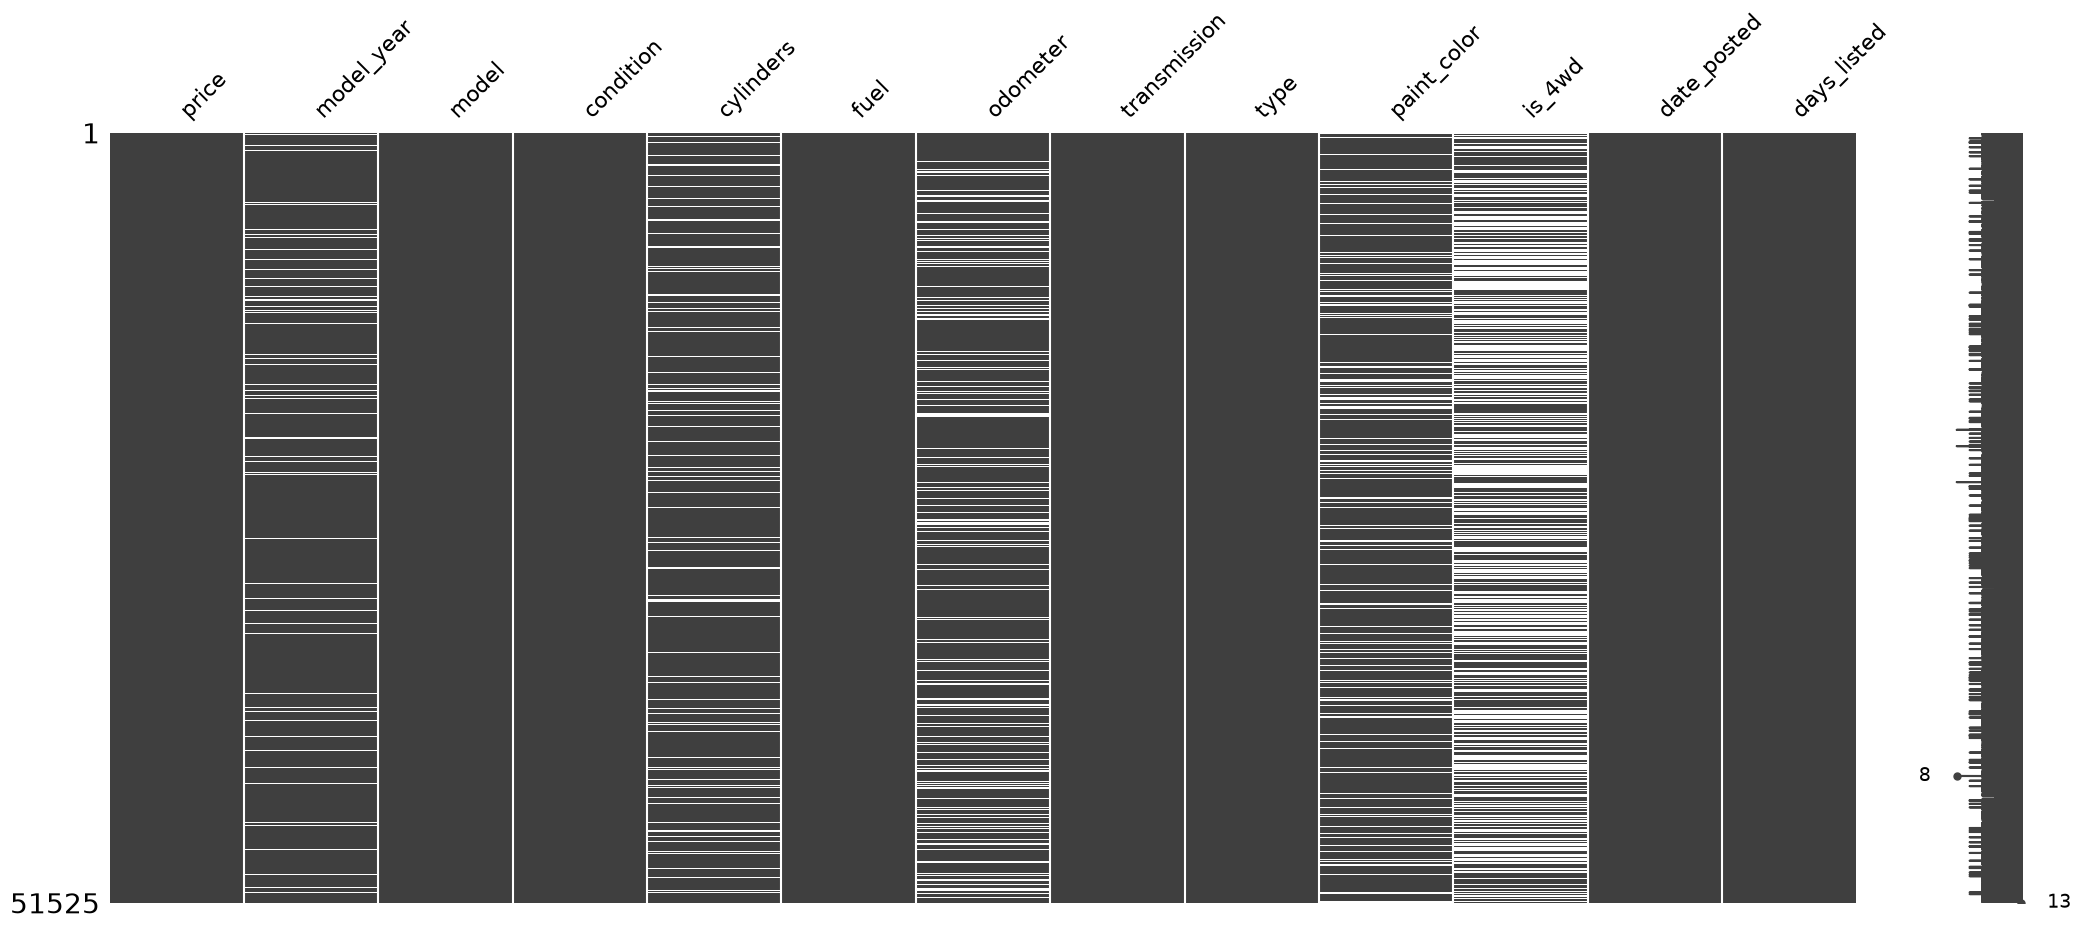

In [62]:
# Nuevamente el valor de nulos por variable 
df.isna().mean().sort_values(ascending=False) * 100 # Nuevamente quiero ver cuantos nulos hay por variable
# o bien, se puede usar: 
df.isna().sum().sort_values(ascending=False)
df.isna().all(axis=1).any() # quiero saber si hay filas en donde los valores nulos se presenten en todas las filas
msno.matrix(df) # Con esta libreria puedo ver un grafico que muestre la presencia (negro) de resgistros y de valores ausentes (espacios en blanco)

In [63]:
# Cuantificar y endener la variable odometer

print(f'La variable contador de kilómetros muestra un total de: {df["odometer"].isna().sum()} valores nulos')# Cuántos son?
print(f'Esto representa un: {df["odometer"].isna().mean()*100} % respecto al total') 
df["odometer"].describe() # Busco comprender la variable. Observo que aunque tengo valores muy altos que parecen atipicos no están distorsionando la media y son muy parecidas. Además, observo registros en cero
# df["odometer"].hist(bins=50) # Con describe y el histograma busco conocer la distribución para saber si podria imputarse el valor con la media o la mediana. Sin embargo noto que etas son muy similares. Por lo tanto, necesito investigar más si es que requeiro imputar
df[df["odometer"]==0]["condition"].value_counts() # Con esto busco saber más sobre la existencia de registros en cero y me doy cuenta que hay autos con 0 kilometraje pero con malas condiciones, por lo que parecen ser errores de registro,, ahora:
df[df["odometer"] == 0]["model_year"].value_counts().sort_index(ascending=False)
df[df["odometer"] == 0][["model_year", "model", "price", "condition", "odometer"]].sort_values("model_year").head(20)

# Debido a que tenemos 182 registros en odometro == 0, busqué relaciones con las otras variables para ver si era posible que fueran registros reales. Sin embargo, me doy cuenta que, 
# pertenecen a registros con un estado del vehiculo variado, que no se relaciona únicamente con autos nuevos. Además, el año modelo también es diverso y se presentan mas registro en cero
# en años modelo tanto recientes como antiguos, mantienen precios similares a los de esos modelos, por lo que seria incongruente que un auto sin usarse se venda al mismo precio que uno usado. 
# Por lo tanto, decido imputarlos como valores faltantes: 

df.loc[df["odometer"] == 0, "odometer"] = np.nan # ahora tengo mas valores faltantes.

La variable contador de kilómetros muestra un total de: 7892 valores nulos
Esto representa un: 15.316836487142163 % respecto al total


,media,mediana,registros
model_year,,,
1908.0,169328.00,169328.0,1
1929.0,NaN,NaN,0
1936.0,30000.00,30000.0,1
1948.0,4000.00,4000.0,1
1949.0,1800.00,1800.0,1
1954.0,3565.00,3565.0,1
1955.0,47180.00,47180.0,1
1958.0,32991.50,32991.5,2
1960.0,16000.00,16000.0,2


,model_year,odometer
model_year,1.000000,-0.484426
odometer,-0.484426,1.000000


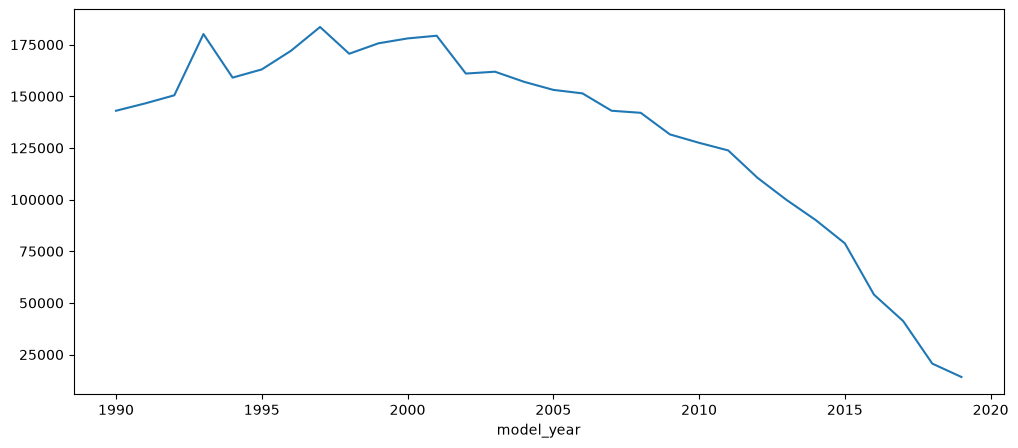

In [64]:
# Relaciones con otras variables que ayuden a explicar la ausencia de información

# La primera relación y la más fuerte es que entre mayor sea el año modelo mayor será su kilometraje.
#  Por lo tanto, ¿Puedo predecir aproximadamente el kilometraje de un vehículo si conozco su año del modelo?

r_km_y_aniomodelo = df.groupby("model_year")["odometer"].agg(media="mean",mediana="median",registros="count")
display(r_km_y_aniomodelo.round(2).head(50))
# Con el anterior codigo podemos observar que a partir de 1990 se presenta una relación clara entre el año modelo y la cantidad de kilometros. 
# Y considero esa fecha además, porque hasta entonces se tienen suficientes registros (>50) para poder establecer esa relación. 

r_km_y_aniomodelo.loc[1990:,"mediana"].plot(figsize=(12,5)) # Con esta grafica podemos observar que entre mas reciente es el modelo menos kilometraje tiene y entre mas antiguo el 
df[["model_year","odometer"]].corr()

In [65]:
# Como he decidido imputarlos, antes quiero hacer una copioa de seguridad en el dataset original
# # Versión original intacta (para comparar)
df_original = df.copy() 

# # Decisión de imputación, ya que he corroborado que existe una relación entre la variable odometer y model_year, puedo entonces
# imputar los valores faltantes con el promedio de kilometraje para cada año.
# Imputación por grupo: 

df["odometer"] = df["odometer"].fillna(df.groupby("model_year")["odometer"].transform("median"))
df["odometer"].isna().sum()  # después de imputar observo que todavia hay 563 registros con valores nulos 
df["odometer"] = df["odometer"].fillna(df["odometer"].median()) # por los que ese grupo los imputo con la media global

In [66]:
# Análisis previo a imputación en la variable cylinders

print(f'La variable de total de cilindros muestra un total de: {df["cylinders"].isna().sum()} valores nulos') # Cuántos son?
print(f'Esto representa un: {df["cylinders"].isna().mean()*100} % respecto al total') # En qué porcentaje se presentan? 
display(df["cylinders"].describe()) # Observo tambien que la media y la mediana son muy cercanas
df.groupby("type")["cylinders"].agg(["median", "std", "count"]) 
cyl_model = df.groupby("model")["cylinders"].agg(["median", "std", "count"])
cyl_model.sample(10).sort_values("model") # lo que observo con model es que la variabilidad de datos en gran parte de los modelos tiene valores bajos. Y en algunos casos si responde a un patron en el que el modelo "general" si tienen la misma cantidad de cilindros. Sin embargo, se presentan modelos con 2 o hasta 4 tipos de cilindro

std_por_model = df.groupby("model")["cylinders"].std() # Con esto, lo que busco es categorizar la variabilidad del nùmero de cilindros por grupos de "modelo". Para saber si es una mejor opción de impoutar datos. 

# Clasificación
print("Modelos con std = 0 (un solo valor de cilindros):", (std_por_model == 0).sum())
print("Modelos con std baja (0 < std <= 0.5):", ((std_por_model > 0) & (std_por_model <= 0.5)).sum())
print("Modelos con std media (0.5 < std <= 1.5):", ((std_por_model > 0.5) & (std_por_model <= 1.5)).sum())
print("Modelos con std alta (> 1.5):", (std_por_model > 1.5).sum())
df["model"].nunique() # Cuento 100 registros distintos de modelos. 
# Con estos resultados se observa que type es más hhomégeneo en como distribuye sus datos de número de cilindros por cada tipo. 
# Los modelos clasificados con una std > 1.5 son 0. Por lo que no tenemos casos en donde sean muy variables los datos y eso es una buena senal para imputarlos
# Antes de ello, quiero terminar de comparar las std de ambas variables con las que se buscó una reóacion que nos pudiera dar elementos para imputar los valores. 

print(f"Std promedio por model: {df.groupby('model')['cylinders'].std().mean():.3f}") # Model tiene una std de 0.57 , considerando una baja-media variabilidad. 
print(f"Std promedio por type: {df.groupby('type')['cylinders'].std().mean():.3f}") # Por type la std es mucho mayor y se acentùa considerando que es una variable numérica continua, por lo que hay más posibiilidades e que sean diferentes. 

df["cylinders"] = df["cylinders"].fillna(df.groupby("model")["cylinders"].transform("median"))

La variable de total de cilindros muestra un total de: 5260 valores nulos
Esto representa un: 10.208636584182436 % respecto al total


count    46265.000000
mean         6.125235
std          1.660360
min          3.000000
25%          4.000000
50%          6.000000
75%          8.000000
max         12.000000
Name: cylinders, dtype: float64

Modelos con std = 0 (un solo valor de cilindros): 7
Modelos con std baja (0 < std <= 0.5): 35
Modelos con std media (0.5 < std <= 1.5): 58
Modelos con std alta (> 1.5): 0
Std promedio por model: 0.574
Std promedio por type: 1.131


In [67]:
df_imputado = df.copy() # Antes de hacer la imputacion 

# Con imputación del número de cilindros que antes eran NA mediante el promedio por grupo de modelo
df_imputado["cylinders"] = df_imputado["cylinders"].fillna(df_imputado.groupby("model")["cylinders"].transform("mean")) 
df_imputado["cylinders"].unique() # Confiro que ya no hay valores nulos.

#df_imputado.head(40) Observo el nuevo dataset limpio

array([ 6.,  4.,  8.,  5., 10.,  3., 12.])

In [75]:
#Imputación de paint color: Al tratarse de una variable de tipo string, la manera más sencilla de imputarlo es de con una cadena de texto desconocido 
df_imputado["paint_color"] = df_imputado["paint_color"].fillna("desconocido")
df_imputado["paint_color"].dtype

# Imputación en la variable año de modelo
df_imputado["model_year"].isna().sum()/len(df_imputado["model_year"])*100 # Que porcentaje de nulos representa los que no tienen año modelo para valorar una posible eliminación.

print("Std promedio por model:", df.groupby("model")["model_year"].std().mean()) # La variabilidad promedio de los datos de año de modelo por grupo de modelo, es de 4.98, esto es menor, respecto a la variable condition que presenta un 6.6 destd
print("Std promedio por condition:", df.groupby("condition")["model_year"].std().mean()) # Con std de 6.6

# Hasta ahorita model sigue siendo la mejor para imputar
df_imputado["model_year"] = df_imputado["model_year"].fillna(df_imputado.groupby("model")["model_year"].transform("mean")) # imputo utilizando a model como grupo para que tome el promedio del año modelo de esos modelos.

df_imputado["model_year"] = df_imputado["model_year"].round().astype(int) # fuerzo a que sea valor de tipo entero, por los decimales que crea con ela imputación
df_imputado["model_year"].unique() # verifico los valores únicos.


Std promedio por model: 4.989244201469225
Std promedio por condition: 6.637620409350209


array([2011, 2009, 2013, 2003, 2017, 2014, 2015, 2012, 2008, 2018, 2010,
       2007, 2004, 2005, 2001, 2006, 1966, 1994, 2019, 2000, 2016, 1993,
       1999, 1997, 2002, 1981, 1995, 1996, 1975, 1998, 1985, 1977, 1987,
       1974, 1990, 1992, 1991, 1972, 1967, 1988, 1969, 1989, 1978, 1965,
       1979, 1968, 1986, 1980, 1964, 1963, 1984, 1982, 1973, 1970, 1955,
       1971, 1976, 1983, 1954, 1962, 1948, 1960, 1908, 1961, 1936, 1949,
       1958, 1929])

## 3. Tratamiento de valores duplicados

In [84]:
# análisis de valores duplicados
   # asi como en el análisis de valores ausentes, en el que se aplicó estsadīstica descriptiva, para mejorar la calidad en los datos y no sólo en la respuesta de casos de negocio
   # quiero empujar el poryecto para comenzar a crear una libreria propia con código reutilizable para siguientes proyectos. Por ello, crearé una funciön que me arrojé comparaciones que me den elementos para decidir como tratar los valores duplicados. 

def analisis_duplicados(df_imputado): # Defino una función que reciba un dataframe 
    
    total = len(df_imputado) # Calculo la longitud del df
    duplicados = df_imputado.duplicated().sum() # Sumo los valores duplicados del df
    unicos = total - duplicados

    porcentaje_dup = duplicados / total * 100 # Paso a valores relativos de duplicados
    porcentaje_unicos = unicos / total * 100  # Paso a valores relativos de ünicos
    
    # Ahora creo un dataframe a partir de un diccionario de datos con pares clave y valor resumiendo los duplicados
    
    tabla_resumen = pd.DataFrame({"Indicador": ["Registros totales", "Registros únicos", "Registros duplicados"], # La tabla tendrá estos nombres de indicador (columnas)
        "Valor absoluto": [total,unicos,duplicados], # Los valores absolutos son llamados desde la primera parte de la función.
        "Valor relativo (%)": [100,porcentaje_unicos, porcentaje_dup]}) # Los valores relativos también son llamados desde la primera parte de la función.

    detalle_duplicados = (df_imputado[df_imputado.duplicated(keep=False)].value_counts().reset_index(name="Frecuencia")) # Creo un filtro para obtener los valores duplicados. Pero, dejo keep = false, porque quiero contar todos los registros, incluyendo el primero que solo mantiene por defecto. 

    if duplicados == 0:
        print("No se encontraron registros duplicados.")
    else:
        print(f"Se encontraron {duplicados} registros duplicados ({porcentaje_dup:})")

    return tabla_resumen, detalle_duplicados, duplicados

tabla_resumen, detalle_duplicados, n_duplicados = analisis_duplicados(df_imputado)

# Con la función para analizar los valores duplicados, no se observan registros completos en donde existan duplicidades, es por ello que no requiero hacer ningun tratamiento. (duplicados explicitos)

display(tabla_resumen)
display(detalle_duplicados)

 

No se encontraron registros duplicados.


,Indicador,Valor absoluto,Valor relativo (%)
0,Registros totales,51525,100.0
1,Registros únicos,51525,100.0
2,Registros duplicados,0,0.0


,price,model_year,model,condition,cylinders,fuel,odometer,transmission,type,paint_color,is_4wd,date_posted,days_listed,Frecuencia


### Conclusiones sobre el preprocesamiento de datos: 



Descripcion de datos:
Tipos de datos:
Valores nulos:
Valores duplicados: No se detectaron valores duplicados.

## Análisis de datos sobre ventas de automoviles


### Como construir un histograma con ploty

In [69]:

# Crear un histograma utilizando plotly.graph_objects
# Se crea una figura vacía y luego se añade un rastro de histograma
fig = go.Figure(data=[go.Histogram(x=df['odometer'])])

# Opcional: Puedes añadir un título al gráfico si lo deseas
fig.update_layout(title_text='Distribución del Odómetro')

# Mostrar el gráfico Plotly
fig.show()

### Como construir un gráfico de dispersión con ploty

In [70]:

# Crear un scatter plot utilizando plotly.graph_objects
# Se crea una figura vacía y luego se añade un rastro de scatter
fig = go.Figure(data=[go.Scatter(x=df['odometer'], y=df['price'], mode='markers')])

# Opcional: Puedes añadir un título al gráfico si lo deseas
fig.update_layout(title_text='Relación entre Odómetro y Precio')

# Mostrar el gráfico Plotly
fig.show()